In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


%matplotlib inline
import sys

from jax import config

config.update("jax_enable_x64", True)


import jax.numpy as jnp

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

In [2]:
from yancc.field import Field
from yancc.preconditioner import DKEPreconditioner
from yancc.species import Hydrogen, LocalMaxwellian
from yancc.trajectories import DKE
from yancc.velocity_grids import MaxwellSpeedGrid, UniformPitchAngleGrid

In [3]:
nt = 5
nz = 9
na = 17
nx = 5

booz_path = "./Benchmark-MONKES-JAX/W7X-EIM/boozmn_wout_w7x_std_v_0.0.txt.nc"
field = Field.from_booz_xform(booz_path, 0.7, nt, nz, cutoff=1e-5)
speedgrid = MaxwellSpeedGrid(nx)
pitchgrid = UniformPitchAngleGrid(na)
species = [LocalMaxwellian.from_scale_lengths(Hydrogen, 1e3, 1e18, -1, -1)]

erho = 1e3

In [4]:
M = DKEPreconditioner(
    field=field,
    pitchgrid=pitchgrid,
    speedgrid=speedgrid,
    species=species,
    Erho=erho,
    background=[],
    potentials=None,
    coarse_N=200,
)
M.print_resolution_summary()
M = M.as_matrix()

A = DKE(
    field=field,
    pitchgrid=pitchgrid,
    speedgrid=speedgrid,
    species=species,
    Erho=erho,
).as_matrix()
I = jnp.eye(A.shape[0])

Grid 0: nx=   5, nα=   7, nθ=   5, nζ=   5, N=875
Grid 1: nx=   5, nα=  17, nθ=   5, nζ=   9, N=3,825


In [5]:
S = I - M @ A

In [6]:
e = jnp.linalg.eigvals(S)

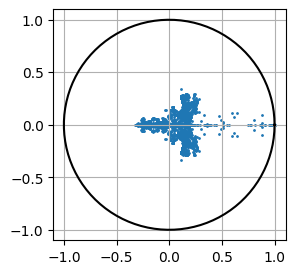

In [7]:
t = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(e.real, e.imag, s=1, alpha=1)
ax.plot(np.cos(t), np.sin(t), c="k")
ax.grid(True)

In [8]:
eA = jnp.linalg.eigvals(A)

In [9]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

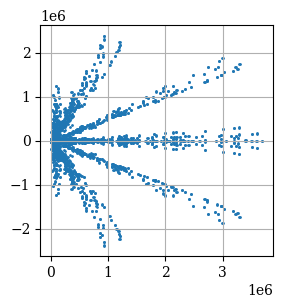

In [10]:
t = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(3, 3))

ax.scatter(eA.real, eA.imag, s=1, alpha=1)
ax.plot(np.cos(t), np.sin(t), c="k")
ax.grid(True)

Text(0.5, 1.0, '$\\mathrm{eig}(I-MA)$')

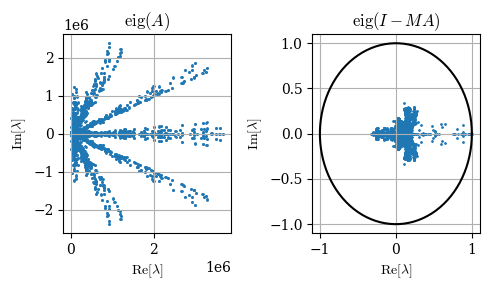

In [11]:
t = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(1, 2, figsize=(5, 3))

ax[0].scatter(eA.real, eA.imag, s=1, alpha=1)
# ax.plot(np.cos(t), np.sin(t), c="k")
ax[0].grid(True)

ax[0].set_xlabel(r"$\mathrm{Re} [\lambda]$")
ax[0].set_ylabel(r"$\mathrm{Im} [\lambda]$")


ax[1].scatter(e.real, e.imag, s=1, alpha=1)
ax[1].plot(np.cos(t), np.sin(t), c="k")
ax[1].grid(True)
ax[1].set_xlabel(r"$\mathrm{Re} [\lambda]$")
ax[1].set_ylabel(r"$\mathrm{Im} [\lambda]$")
fig.set_tight_layout(True)
ax[0].set_title(r"$\mathrm{eig}(A)$")
ax[1].set_title(r"$\mathrm{eig}(I-MA)$")

In [12]:
fig.savefig("spectrum.pdf")
fig.savefig("spectrum.png")